In [5]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 6.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.9 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.1/809.1 kB 8.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: sympy
    Found existing installation: sympy 1.12
    Uninstalling sympy-1.12:
      Successfully uninstalled sympy-1.12


In [7]:
!pip install torch torchvision torchaudio tqdm

In [3]:
import zipfile
import os

zip_path = "archive.zip"  
extract_dir = "./archive_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


for root, dirs, files in os.walk(extract_dir):
    print(root, len(files), "files")
    
    if root.count(os.sep) - extract_dir.count(os.sep) >= 2:
        break


./archive_extracted 0 files
./archive_extracted/split 0 files
./archive_extracted/split/test 0 files


Type: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Sample number: 2929
Training set: 2343, Validation set: 292, Test set: 294


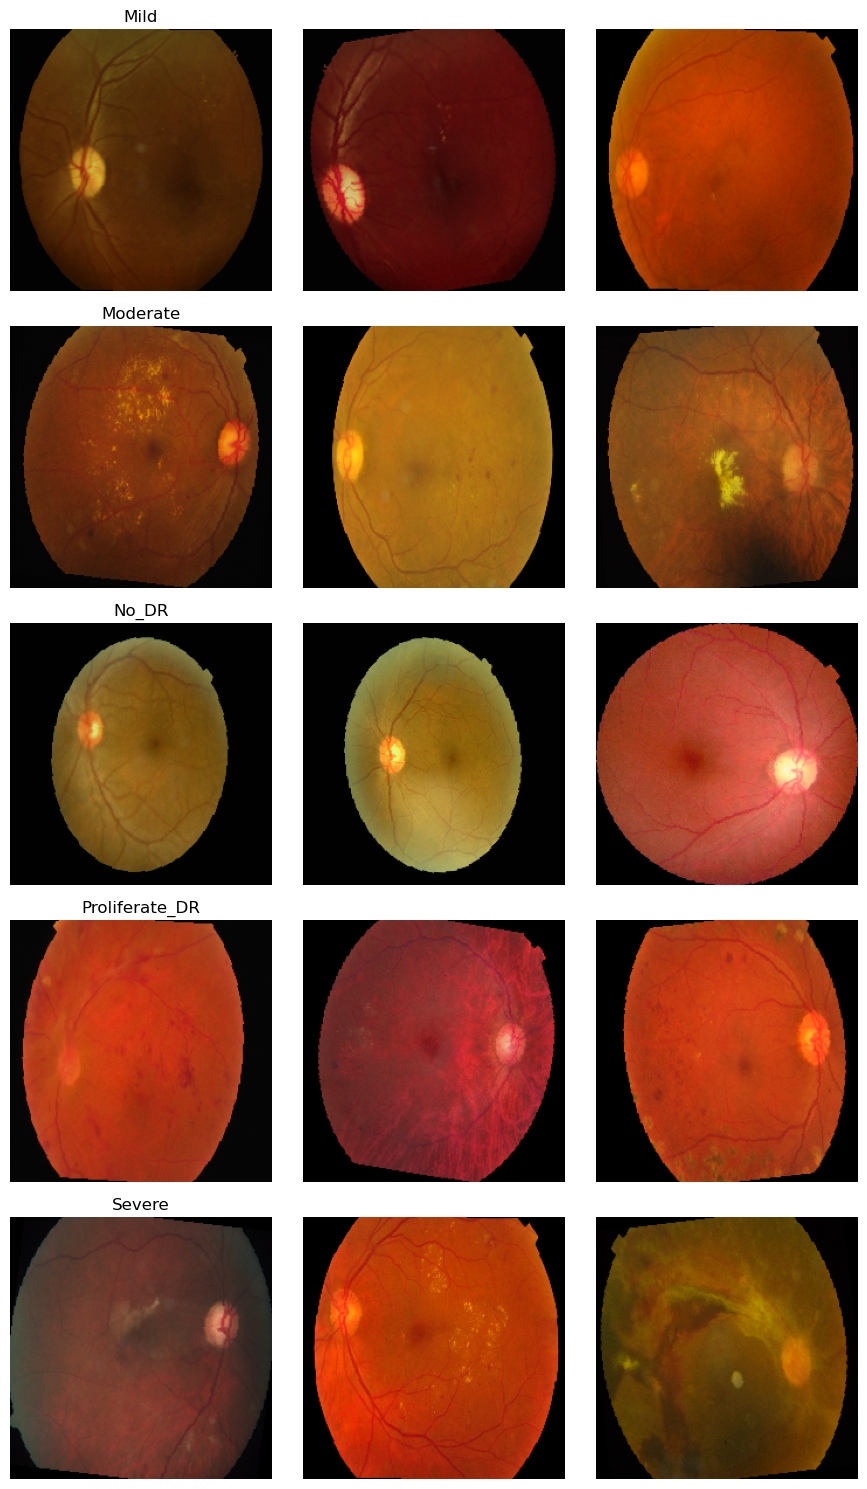

In [9]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt


IMG_SIZE = 224  

# Preprocessing process
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


TRAIN_DIR = "./archive_extracted/split/train"


full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)


print("Type:", full_dataset.classes)
print("Sample number:", len(full_dataset))


train_size = int(0.8 * len(full_dataset))  
val_size = int(0.1 * len(full_dataset))    
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  
)

print(f"Training set: {len(train_dataset)}, Validation set: {len(val_dataset)}, Test set: {len(test_dataset)}")

# -------- Visualize the preprocessed images of each category ----------
def show_images(dataset, classes, num_per_class=3):
    fig, axs = plt.subplots(len(classes), num_per_class, figsize=(num_per_class*3, len(classes)*3))
    
    for class_idx, class_name in enumerate(classes):
        
        indices = [i for i, (_, label) in enumerate(dataset) if label == class_idx]
        chosen = torch.randperm(len(indices))[:num_per_class]  
        for j, idx in enumerate(chosen):
            img, _ = dataset[indices[idx]]
            img = img.permute(1, 2, 0) 
            img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])  
            img = img.clamp(0,1)  
            axs[class_idx, j].imshow(img)
            axs[class_idx, j].axis("off")
            if j == 0:
                axs[class_idx, j].set_title(class_name, fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Display each type of image
show_images(full_dataset, full_dataset.classes, num_per_class=3)


In [10]:
from torch.utils.data import DataLoader

# Create a DataLoader
BATCH_SIZE = 32  
NUM_WORKERS = 2  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 74, Val batches: 10, Test batches: 10


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


def bn_to_gn(module: nn.Module, groups: int = 16):
    for name, child in module.named_children():
        if isinstance(child, (nn.BatchNorm2d, nn.BatchNorm1d)):
            num_channels = child.num_features
            gn = nn.GroupNorm(num_groups=min(groups, num_channels), num_channels=num_channels)
            setattr(module, name, gn)
        else:
            bn_to_gn(child, groups)
    return module



def build_model(num_classes: int, gn_groups: int = 16):
    model = models.resnet18(weights=None)  # 也可换 weights='IMAGENET1K_V1'
    model = bn_to_gn(model, groups=gn_groups)
    in_feat = model.fc.in_features
    model.fc = nn.Linear(in_feat, num_classes)
    return model



class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


def fedprox_penalty(model: nn.Module, global_state_dict: dict | None, mu: float, device: str):
    if mu <= 0.0 or global_state_dict is None:
        return torch.tensor(0.0, device=device)
    prox = torch.tensor(0.0, device=device)
    for name, p in model.named_parameters():
        if p.requires_grad and name in global_state_dict:
            prox = prox + torch.sum((p - global_state_dict[name].to(device)) ** 2)
    return 0.5 * mu * prox



def mixup_data(x, y, alpha=0.4):
    if alpha <= 0.0:
        return x, y, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return x_mix, (y_a, y_b), lam

def mixup_criterion(loss_fn, pred, y_mix, lam):
    y_a, y_b = y_mix
    return lam * loss_fn(pred, y_a) + (1 - lam) * loss_fn(pred, y_b)



def train_one_epoch(model, loader, optimizer, device,
                    criterion_type='ce', class_weights=None,
                    label_smoothing=0.1,
                    global_state_dict=None, fedprox_mu=0.0,
                    mixup_alpha=0.0):
    model.train()
    if criterion_type == 'ce':
        loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    elif criterion_type == 'focal':
        loss_fn = FocalLoss(weight=class_weights)
    else:
        raise ValueError("criterion_type must be 'ce' or 'focal'")

    total, correct, loss_sum = 0, 0, 0.0

    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)

        
        images, y_mix, lam = mixup_data(images, targets, alpha=mixup_alpha)

        logits = model(images)

        if mixup_alpha > 0.0:
            base_loss = mixup_criterion(loss_fn, logits, y_mix, lam)
            
            preds = logits.argmax(1)
            correct += preds.eq(targets).sum().item()
        else:
            base_loss = loss_fn(logits, targets)
            preds = logits.argmax(1)
            correct += preds.eq(targets).sum().item()

        prox = fedprox_penalty(model, global_state_dict, mu=fedprox_mu, device=device)
        loss = base_loss + prox

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        bs = targets.size(0)
        total += bs
        loss_sum += loss.item() * bs

    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total, correct, loss_sum = 0, 0, 0.0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        logits = model(images)
        loss = loss_fn(logits, targets)
        preds = logits.argmax(1)
        total += targets.size(0)
        correct += preds.eq(targets).sum().item()
        loss_sum += loss.item() * targets.size(0)
    return loss_sum / total, correct / total


def fit_noniid(train_loader, val_loader, test_loader, num_classes,
               epochs=10, lr=1e-3, weight_decay=1e-4,
               criterion_type='ce', label_smoothing=0.1,
               class_weights=None, gn_groups=16,
               fedprox_mu=0.0, mixup_alpha=0.0,
               global_state_dict=None):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = build_model(num_classes=num_classes, gn_groups=gn_groups).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val, best_state = 0.0, None
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, device,
            criterion_type=criterion_type,
            class_weights=class_weights,
            label_smoothing=label_smoothing,
            global_state_dict=global_state_dict,
            fedprox_mu=fedprox_mu,
            mixup_alpha=mixup_alpha
        )
        va_loss, va_acc = evaluate(model, val_loader, device)
        scheduler.step()
        print(f"[Epoch {ep:02d}] train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}")
        if va_acc > best_val:
            best_val, best_state = va_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc = evaluate(model, test_loader, device)
    print(f"Test  loss/acc: {te_loss:.4f}/{te_acc:.3f}")
    return model



==== Baseline-A | epochs=6, lr=0.001, criterion=ce, smoothing=0.1, fedprox_mu=0.0, mixup=0.0 ====
[Baseline-A] Epoch 01: Train 1.4588/0.511 | Val 1.2342/0.589
[Baseline-A] Epoch 02: Train 1.2410/0.592 | Val 1.2326/0.586
[Baseline-A] Epoch 03: Train 1.2060/0.603 | Val 1.1275/0.616
[Baseline-A] Epoch 04: Train 1.1701/0.623 | Val 1.1574/0.589
[Baseline-A] Epoch 05: Train 1.0913/0.665 | Val 1.0466/0.630
[Baseline-A] Epoch 06: Train 1.0448/0.684 | Val 1.0036/0.630
✅ Baseline-A | Test loss=0.9391, acc=0.646 | Best Val acc=0.630
💾 Saved best model to: model_A_best.pt

==== FedProx-C | epochs=6, lr=0.0008, criterion=ce, smoothing=0.1, fedprox_mu=0.001, mixup=0.0 ====
[FedProx-C] Epoch 01: Train 1.4362/0.502 | Val 1.1358/0.613
[FedProx-C] Epoch 02: Train 1.2423/0.598 | Val 1.1693/0.620
[FedProx-C] Epoch 03: Train 1.1644/0.640 | Val 1.1139/0.647
[FedProx-C] Epoch 04: Train 1.0956/0.665 | Val 1.0540/0.630
[FedProx-C] Epoch 05: Train 1.0543/0.678 | Val 1.0195/0.623
[FedProx-C] Epoch 06: Train 1.0

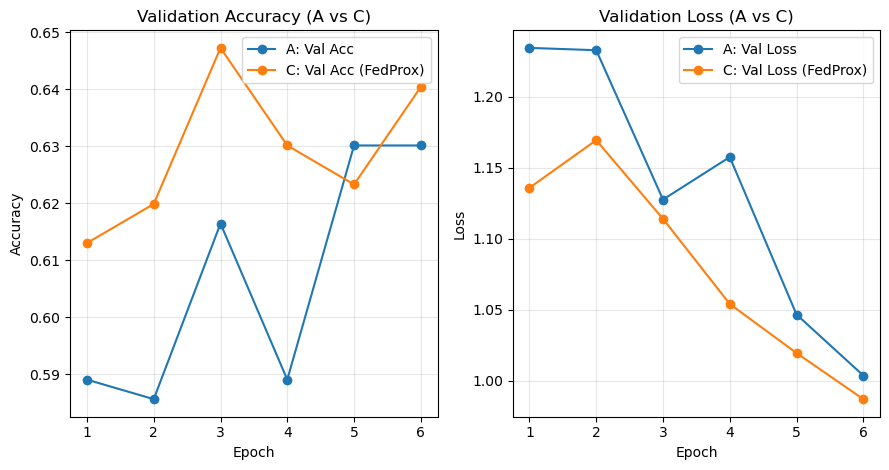

In [12]:
import torch
import matplotlib.pyplot as plt


def fit_and_log(run_name,
                train_loader, val_loader, test_loader, num_classes,
                epochs=6, lr=1e-3, weight_decay=1e-4,
                criterion_type='ce', label_smoothing=0.1,
                fedprox_mu=0.0, mixup_alpha=0.0,
                global_state_dict=None,
                gn_groups=16,
                save_path=None):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = build_model(num_classes=num_classes, gn_groups=gn_groups).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val = 0.0
    best_state = None

    print(f"\n==== {run_name} | epochs={epochs}, lr={lr}, criterion={criterion_type}, "
          f"smoothing={label_smoothing}, fedprox_mu={fedprox_mu}, mixup={mixup_alpha} ====")

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, device,
            criterion_type=criterion_type,
            label_smoothing=label_smoothing,
            global_state_dict=global_state_dict,
            fedprox_mu=fedprox_mu,
            mixup_alpha=mixup_alpha
        )
        va_loss, va_acc = evaluate(model, val_loader, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        print(f"[{run_name}] Epoch {ep:02d}: Train {tr_loss:.4f}/{tr_acc:.3f} | "
              f"Val {va_loss:.4f}/{va_acc:.3f}")

        if va_acc > best_val:
            best_val = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc = evaluate(model, test_loader, device)
    print(f"✅ {run_name} | Test loss={te_loss:.4f}, acc={te_acc:.3f} | Best Val acc={best_val:.3f}")

    
    if save_path is not None:
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved best model to: {save_path}")

    return history


num_classes = len(full_dataset.classes)


# A (base line) 
hist_A = fit_and_log(
    run_name="Baseline-A",
    train_loader=train_loader, val_loader=val_loader, test_loader=test_loader,
    num_classes=num_classes,
    epochs=6, lr=1e-3,
    criterion_type='ce', label_smoothing=0.1,
    fedprox_mu=0.0, mixup_alpha=0.0,
    global_state_dict=None,
    save_path="model_A_best.pt"
)

# C (Non-IID, Uneven feature distribution)
hist_C = fit_and_log(
    run_name="FedProx-C",
    train_loader=train_loader, val_loader=val_loader, test_loader=test_loader,
    num_classes=num_classes,
    epochs=6, lr=8e-4,
    criterion_type='ce', label_smoothing=0.1,
    fedprox_mu=1e-3, mixup_alpha=0.0,
    global_state_dict=None,             
    save_path="model_C_fedprox_best.pt"
)


epochs_range = range(1, len(hist_A['val_acc']) + 1)

plt.figure(figsize=(9,4.8))
plt.subplot(1,2,1)
plt.plot(epochs_range, hist_A['val_acc'], marker='o', label='A: Val Acc')
plt.plot(epochs_range, hist_C['val_acc'], marker='o', label='C: Val Acc (FedProx)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy (A vs C)')
plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, hist_A['val_loss'], marker='o', label='A: Val Loss')
plt.plot(epochs_range, hist_C['val_loss'], marker='o', label='C: Val Loss (FedProx)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Validation Loss (A vs C)')
plt.grid(True, alpha=0.3); plt.legend()

plt.tight_layout()
plt.show()

